# Transformer Architecture Implementation (PyTorch)
## DAM202 - Practical 6

**Implementation of "Attention Is All You Need"**

---

## Step 1: Environment Setup

Import all necessary libraries.

In [24]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create a directory for saving models/outputs
output_dir = '/content/drive/MyDrive/DAM202_dataset/Practical6'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory created: /content/drive/MyDrive/DAM202_dataset/Practical6


In [25]:
# Import PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt

# Checking if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## Step 2: Hyperparameters (Base Model Configuration)

Define all standard hyperparameters.

In [26]:
# Transformer Base Model Hyperparameters
class TransformerConfig:
    def __init__(self):
        # Model dimensions
        self.d_model = 512          # Model dimension (embedding size)
        self.n_heads = 8            # Number of attention heads
        self.d_k = 64               # Dimension of K, Q (d_model / n_heads)
        self.d_v = 64               # Dimension of V (d_model / n_heads)
        self.d_ff = 2048            # Feed-forward inner dimension

        # Architecture
        self.n_layers = 6           # Number of encoder/decoder layers (N)
        self.dropout = 0.1          # Dropout rate

        # Vocabulary (for testing)
        self.src_vocab_size = 10000 # Source vocabulary size
        self.tgt_vocab_size = 10000 # Target vocabulary size
        self.max_seq_len = 100      # Maximum sequence length

        # Special tokens
        self.pad_idx = 0            # Padding token index

# Instantiate config
config = TransformerConfig()
print("Transformer Configuration:")
print(f"  d_model: {config.d_model}")
print(f"  n_heads: {config.n_heads}")
print(f"  d_k/d_v: {config.d_k}/{config.d_v}")
print(f"  d_ff: {config.d_ff}")
print(f"  n_layers: {config.n_layers}")
print(f"  dropout: {config.dropout}")

Transformer Configuration:
  d_model: 512
  n_heads: 8
  d_k/d_v: 64/64
  d_ff: 2048
  n_layers: 6
  dropout: 0.1


## Step 3: Positional Encoding

**Why?** Transformers have no recurrence or convolution, so we need to inject position information.

**Formula:**
- $PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$
- $PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$

where `pos` is position and `i` is dimension.

In [27]:
class PositionalEncoding(nn.Module):
    """
    Implements fixed sinusoidal positional encoding.

    Input: (batch_size, seq_len, d_model)
    Output: (batch_size, seq_len, d_model)
    """
    def __init__(self, d_model, max_seq_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)

        # Compute the div_term for the denominator
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            (-math.log(10000.0) / d_model))

        # Apply sin to even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        # Apply cos to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension: (1, max_seq_len, d_model)
        pe = pe.unsqueeze(0)

        # Register as buffer (not a parameter, but part of module state)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Input embeddings (batch_size, seq_len, d_model)
        Returns:
            x + positional encoding (batch_size, seq_len, d_model)
        """
        # Add positional encoding to input
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Test Positional Encoding
print("Testing Positional Encoding...")
pe_test = PositionalEncoding(d_model=config.d_model, max_seq_len=config.max_seq_len)
test_input = torch.randn(2, 10, config.d_model)  # (batch=2, seq_len=10, d_model=512)
output = pe_test(test_input)
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {output.shape}")
print("  ✓ Positional Encoding working correctly!\n")

Testing Positional Encoding...
  Input shape: torch.Size([2, 10, 512])
  Output shape: torch.Size([2, 10, 512])
  ✓ Positional Encoding working correctly!



### Visualize Positional Encoding

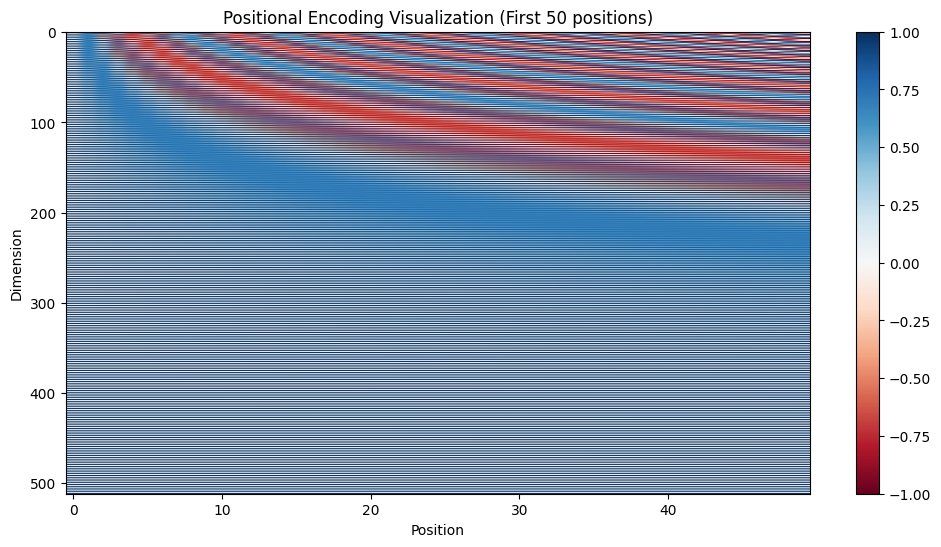

In [28]:
# Visualize positional encoding
plt.figure(figsize=(12, 6))
pe_matrix = pe_test.pe[0, :50, :].detach().numpy()  # First 50 positions
plt.imshow(pe_matrix.T, aspect='auto', cmap='RdBu')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Positional Encoding Visualization (First 50 positions)')
plt.colorbar()
plt.show()

## Step 4: Scaled Dot-Product Attention

**Core attention mechanism:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Why scaling?** Prevents softmax from saturating when $d_k$ is large.

In [29]:
def scaled_dot_product_attention(Q, K, V, mask=None, dropout=None):
    """
    Compute Scaled Dot-Product Attention.

    Args:
        Q: Query matrix (batch_size, n_heads, seq_len_q, d_k)
        K: Key matrix (batch_size, n_heads, seq_len_k, d_k)
        V: Value matrix (batch_size, n_heads, seq_len_v, d_v)
        mask: Optional mask (batch_size, 1, 1, seq_len_k) or (batch_size, 1, seq_len_q, seq_len_k)
        dropout: Optional dropout layer

    Returns:
        output: Attention output (batch_size, n_heads, seq_len_q, d_v)
        attention_weights: Attention weights (batch_size, n_heads, seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)

    # Step 1: Compute attention scores: QK^T / sqrt(d_k)
    # (batch_size, n_heads, seq_len_q, d_k) @ (batch_size, n_heads, d_k, seq_len_k)
    # -> (batch_size, n_heads, seq_len_q, seq_len_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Step 2: Apply mask (if provided)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # Step 3: Apply softmax to get attention weights
    attention_weights = F.softmax(scores, dim=-1)

    # Step 4: Apply dropout (if provided)
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # Step 5: Multiply by values
    # (batch_size, n_heads, seq_len_q, seq_len_k) @ (batch_size, n_heads, seq_len_v, d_v)
    # -> (batch_size, n_heads, seq_len_q, d_v)
    output = torch.matmul(attention_weights, V)

    return output, attention_weights

# Test Scaled Dot-Product Attention
print("Testing Scaled Dot-Product Attention...")
batch_size, n_heads, seq_len, d_k = 2, 8, 10, 64
Q_test = torch.randn(batch_size, n_heads, seq_len, d_k)
K_test = torch.randn(batch_size, n_heads, seq_len, d_k)
V_test = torch.randn(batch_size, n_heads, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q_test, K_test, V_test)
print(f"  Q shape: {Q_test.shape}")
print(f"  K shape: {K_test.shape}")
print(f"  V shape: {V_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Attention weights shape: {attn_weights.shape}")
print("  ✓ Scaled Dot-Product Attention working correctly!\n")

Testing Scaled Dot-Product Attention...
  Q shape: torch.Size([2, 8, 10, 64])
  K shape: torch.Size([2, 8, 10, 64])
  V shape: torch.Size([2, 8, 10, 64])
  Output shape: torch.Size([2, 8, 10, 64])
  Attention weights shape: torch.Size([2, 8, 10, 10])
  ✓ Scaled Dot-Product Attention working correctly!



## Step 5: Multi-Head Attention

**Key idea:** Instead of one attention function, use multiple parallel attention heads.

**Process:**
1. Linear projections: $Q_i = XW_i^Q$, $K_i = XW_i^K$, $V_i = XW_i^V$
2. Apply attention in parallel for each head
3. Concatenate outputs
4. Final linear projection

In [30]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism.

    Input: (batch_size, seq_len, d_model)
    Output: (batch_size, seq_len, d_model)
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x, batch_size):
        """
        Split the last dimension into (n_heads, d_k).

        Args:
            x: (batch_size, seq_len, d_model)
        Returns:
            (batch_size, n_heads, seq_len, d_k)
        """
        x = x.view(batch_size, -1, self.n_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: (batch_size, seq_len_q, d_model)
            key: (batch_size, seq_len_k, d_model)
            value: (batch_size, seq_len_v, d_model)
            mask: Optional mask

        Returns:
            output: (batch_size, seq_len_q, d_model)
            attention_weights: (batch_size, n_heads, seq_len_q, seq_len_k)
        """
        batch_size = query.size(0)

        # Step 1: Linear projections
        Q = self.W_q(query)  # (batch_size, seq_len_q, d_model)
        K = self.W_k(key)    # (batch_size, seq_len_k, d_model)
        V = self.W_v(value)  # (batch_size, seq_len_v, d_model)

        # Step 2: Split into multiple heads
        Q = self.split_heads(Q, batch_size)  # (batch_size, n_heads, seq_len_q, d_k)
        K = self.split_heads(K, batch_size)  # (batch_size, n_heads, seq_len_k, d_k)
        V = self.split_heads(V, batch_size)  # (batch_size, n_heads, seq_len_v, d_k)

        # Step 3: Apply scaled dot-product attention
        attn_output, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask=mask, dropout=self.dropout
        )
        # attn_output: (batch_size, n_heads, seq_len_q, d_k)

        # Step 4: Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        # (batch_size, seq_len_q, n_heads, d_k)
        attn_output = attn_output.view(batch_size, -1, self.d_model)
        # (batch_size, seq_len_q, d_model)

        # Step 5: Final linear projection
        output = self.W_o(attn_output)  # (batch_size, seq_len_q, d_model)

        return output, attention_weights

# Test Multi-Head Attention
print("Testing Multi-Head Attention...")
mha_test = MultiHeadAttention(d_model=config.d_model, n_heads=config.n_heads)
x_test = torch.randn(2, 10, config.d_model)  # (batch=2, seq_len=10, d_model=512)
output, attn_weights = mha_test(x_test, x_test, x_test)
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Attention weights shape: {attn_weights.shape}")
print("  ✓ Multi-Head Attention working correctly!\n")

Testing Multi-Head Attention...
  Input shape: torch.Size([2, 10, 512])
  Output shape: torch.Size([2, 10, 512])
  Attention weights shape: torch.Size([2, 8, 10, 10])
  ✓ Multi-Head Attention working correctly!



## Step 6: Position-wise Feed-Forward Network

**Two linear transformations with ReLU:**

$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

Applied identically to each position separately.

In [31]:
class PositionWiseFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.

    Two linear transformations with ReLU activation.
    Input: (batch_size, seq_len, d_model)
    Output: (batch_size, seq_len, d_model)
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionWiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, d_model)
        Returns:
            (batch_size, seq_len, d_model)
        """
        # First linear + ReLU + dropout
        x = self.dropout(F.relu(self.linear1(x)))
        # Second linear
        x = self.linear2(x)
        return x

# Test Feed-Forward Network
print("Testing Position-wise Feed-Forward Network...")
ffn_test = PositionWiseFeedForward(d_model=config.d_model, d_ff=config.d_ff)
x_test = torch.randn(2, 10, config.d_model)
output = ffn_test(x_test)
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {output.shape}")
print("  ✓ Feed-Forward Network working correctly!\n")

Testing Position-wise Feed-Forward Network...
  Input shape: torch.Size([2, 10, 512])
  Output shape: torch.Size([2, 10, 512])
  ✓ Feed-Forward Network working correctly!



## Step 7: Encoder Layer

**Structure:**
1. Multi-Head Self-Attention
2. Add & Norm (Residual connection + Layer Normalization)
3. Feed-Forward Network
4. Add & Norm

In [32]:
class EncoderLayer(nn.Module):
    """
    Single Encoder Layer.

    Contains:
    - Multi-Head Self-Attention
    - Position-wise Feed-Forward Network
    - Residual connections and Layer Normalization
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()

        # Sub-layer 1: Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Sub-layer 2: Feed-Forward Network
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x: (batch_size, seq_len, d_model)
            mask: Optional padding mask
        Returns:
            (batch_size, seq_len, d_model)
        """
        # Sub-layer 1: Self-Attention + Add & Norm
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Sub-layer 2: FFN + Add & Norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        return x

# Test Encoder Layer
print("Testing Encoder Layer...")
enc_layer_test = EncoderLayer(d_model=config.d_model, n_heads=config.n_heads,
                               d_ff=config.d_ff)
x_test = torch.randn(2, 10, config.d_model)
output = enc_layer_test(x_test)
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {output.shape}")
print("  ✓ Encoder Layer working correctly!\n")

Testing Encoder Layer...
  Input shape: torch.Size([2, 10, 512])
  Output shape: torch.Size([2, 10, 512])
  ✓ Encoder Layer working correctly!



## Step 8: Decoder Layer

**Structure:**
1. Masked Multi-Head Self-Attention (with look-ahead mask)
2. Add & Norm
3. Multi-Head Cross-Attention (attending to encoder output)
4. Add & Norm
5. Feed-Forward Network
6. Add & Norm

In [33]:
class DecoderLayer(nn.Module):
    """
    Single Decoder Layer.

    Contains:
    - Masked Multi-Head Self-Attention
    - Multi-Head Cross-Attention (encoder-decoder attention)
    - Position-wise Feed-Forward Network
    - Residual connections and Layer Normalization
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # Sub-layer 1: Masked Self-Attention
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Sub-layer 2: Cross-Attention (encoder-decoder attention)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Sub-layer 3: Feed-Forward Network
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        """
        Args:
            x: Decoder input (batch_size, tgt_seq_len, d_model)
            enc_output: Encoder output (batch_size, src_seq_len, d_model)
            src_mask: Source padding mask for cross-attention
            tgt_mask: Target mask (padding + look-ahead) for self-attention
        Returns:
            (batch_size, tgt_seq_len, d_model)
        """
        # Sub-layer 1: Masked Self-Attention + Add & Norm
        self_attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_output))

        # Sub-layer 2: Cross-Attention + Add & Norm
        cross_attn_output, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_output))

        # Sub-layer 3: FFN + Add & Norm
        ffn_output = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_output))

        return x

# Test Decoder Layer
print("Testing Decoder Layer...")
dec_layer_test = DecoderLayer(d_model=config.d_model, n_heads=config.n_heads,
                               d_ff=config.d_ff)
x_test = torch.randn(2, 10, config.d_model)
enc_output_test = torch.randn(2, 12, config.d_model)
output = dec_layer_test(x_test, enc_output_test)
print(f"  Decoder input shape: {x_test.shape}")
print(f"  Encoder output shape: {enc_output_test.shape}")
print(f"  Output shape: {output.shape}")
print("  ✓ Decoder Layer working correctly!\n")

Testing Decoder Layer...
  Decoder input shape: torch.Size([2, 10, 512])
  Encoder output shape: torch.Size([2, 12, 512])
  Output shape: torch.Size([2, 10, 512])
  ✓ Decoder Layer working correctly!



## Step 9: Complete Encoder Stack

Stack N=6 encoder layers with embeddings and positional encoding.

In [34]:
class Encoder(nn.Module):
    """
    Complete Encoder: N stacked encoder layers.

    Includes:
    - Input embedding
    - Positional encoding
    - N encoder layers
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 max_seq_len, dropout=0.1):
        super(Encoder, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Stack of N encoder layers
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, src, src_mask=None):
        """
        Args:
            src: Source token indices (batch_size, src_seq_len)
            src_mask: Source padding mask
        Returns:
            (batch_size, src_seq_len, d_model)
        """
        # Embedding + scaling
        x = self.embedding(src) * math.sqrt(self.d_model)

        # Add positional encoding
        x = self.pos_encoding(x)

        # Pass through each encoder layer
        for layer in self.layers:
            x = layer(x, src_mask)

        return x

# Test Encoder
print("Testing Complete Encoder...")
encoder_test = Encoder(vocab_size=config.src_vocab_size, d_model=config.d_model,
                       n_layers=config.n_layers, n_heads=config.n_heads,
                       d_ff=config.d_ff, max_seq_len=config.max_seq_len)
src_test = torch.randint(0, config.src_vocab_size, (2, 10))  # Random token indices
output = encoder_test(src_test)
print(f"  Input shape: {src_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Number of encoder layers: {config.n_layers}")
print("  ✓ Complete Encoder working correctly!\n")

Testing Complete Encoder...
  Input shape: torch.Size([2, 10])
  Output shape: torch.Size([2, 10, 512])
  Number of encoder layers: 6
  ✓ Complete Encoder working correctly!



## Step 10: Complete Decoder Stack

Stack N=6 decoder layers with embeddings and positional encoding.

In [35]:
class Decoder(nn.Module):
    """
    Complete Decoder: N stacked decoder layers.

    Includes:
    - Output embedding
    - Positional encoding
    - N decoder layers
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 max_seq_len, dropout=0.1):
        super(Decoder, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        # Stack of N decoder layers
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        """
        Args:
            tgt: Target token indices (batch_size, tgt_seq_len)
            enc_output: Encoder output (batch_size, src_seq_len, d_model)
            src_mask: Source padding mask
            tgt_mask: Target mask (padding + look-ahead)
        Returns:
            (batch_size, tgt_seq_len, d_model)
        """
        # Embedding + scaling
        x = self.embedding(tgt) * math.sqrt(self.d_model)

        # Add positional encoding
        x = self.pos_encoding(x)

        # Pass through each decoder layer
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)

        return x

# Test Decoder
print("Testing Complete Decoder...")
decoder_test = Decoder(vocab_size=config.tgt_vocab_size, d_model=config.d_model,
                       n_layers=config.n_layers, n_heads=config.n_heads,
                       d_ff=config.d_ff, max_seq_len=config.max_seq_len)
tgt_test = torch.randint(0, config.tgt_vocab_size, (2, 8))
enc_output_test = torch.randn(2, 10, config.d_model)
output = decoder_test(tgt_test, enc_output_test)
print(f"  Target input shape: {tgt_test.shape}")
print(f"  Encoder output shape: {enc_output_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Number of decoder layers: {config.n_layers}")
print("  ✓ Complete Decoder working correctly!\n")

Testing Complete Decoder...
  Target input shape: torch.Size([2, 8])
  Encoder output shape: torch.Size([2, 10, 512])
  Output shape: torch.Size([2, 8, 512])
  Number of decoder layers: 6
  ✓ Complete Decoder working correctly!



## Step 11: Masking Functions

Implement both padding mask and look-ahead mask.

In [37]:
def create_padding_mask(seq, pad_idx=0):
    """
    Create padding mask to ignore <PAD> tokens.

    Args:
        seq: Token sequence (batch_size, seq_len)
        pad_idx: Padding token index
    Returns:
        mask: (batch_size, 1, 1, seq_len)
    """
    # Create mask where pad tokens are False (0)
    mask = (seq != pad_idx).unsqueeze(1).unsqueeze(2)
    return mask  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(size):
    """
    Create look-ahead (causal) mask for decoder self-attention.
    Prevents attention to future positions.

    Args:
        size: Sequence length
    Returns:
        mask: (1, size, size) with upper triangle masked
    """
    # Create lower triangular matrix (convert to bool)
    mask = torch.tril(torch.ones((size, size))).unsqueeze(0).bool()
    return mask  # (1, size, size)

def create_target_mask(tgt, pad_idx=0):
    """
    Create combined mask for decoder: padding + look-ahead.

    Args:
        tgt: Target sequence (batch_size, tgt_seq_len)
        pad_idx: Padding token index
    Returns:
        Combined mask (batch_size, 1, tgt_seq_len, tgt_seq_len)
    """
    tgt_seq_len = tgt.size(1)

    # Padding mask
    tgt_padding_mask = create_padding_mask(tgt, pad_idx)
    # (batch_size, 1, 1, tgt_seq_len)

    # Look-ahead mask
    look_ahead_mask = create_look_ahead_mask(tgt_seq_len).to(tgt.device)
    # (1, tgt_seq_len, tgt_seq_len)

    # Combine masks
    tgt_mask = tgt_padding_mask & look_ahead_mask.unsqueeze(0)
    # (batch_size, 1, tgt_seq_len, tgt_seq_len)

    return tgt_mask

# Test masking functions
print("Testing Masking Functions...")

# Test padding mask
src_test = torch.tensor([[1, 2, 3, 0, 0], [4, 5, 0, 0, 0]])
src_mask = create_padding_mask(src_test, pad_idx=0)
print(f"Source sequence shape: {src_test.shape}")
print(f"Source padding mask shape: {src_mask.shape}")
print(f"Source mask:\n{src_mask[0, 0, 0]}")

# Test look-ahead mask
look_ahead = create_look_ahead_mask(5)
print(f"\nLook-ahead mask shape: {look_ahead.shape}")
print(f"Look-ahead mask:\n{look_ahead[0]}")

# Test combined target mask
tgt_test = torch.tensor([[1, 2, 3, 0], [4, 5, 6, 7]])
tgt_mask = create_target_mask(tgt_test, pad_idx=0)
print(f"\nTarget sequence shape: {tgt_test.shape}")
print(f"Target mask shape: {tgt_mask.shape}")
print(f"Target mask (first batch):\n{tgt_mask[0, 0]}")
print("  ✓ Masking functions working correctly!\n")

Testing Masking Functions...
Source sequence shape: torch.Size([2, 5])
Source padding mask shape: torch.Size([2, 1, 1, 5])
Source mask:
tensor([ True,  True,  True, False, False])

Look-ahead mask shape: torch.Size([1, 5, 5])
Look-ahead mask:
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True]])

Target sequence shape: torch.Size([2, 4])
Target mask shape: torch.Size([2, 1, 4, 4])
Target mask (first batch):
tensor([[ True, False, False, False],
        [ True,  True, False, False],
        [ True,  True,  True, False],
        [ True,  True,  True, False]])
  ✓ Masking functions working correctly!



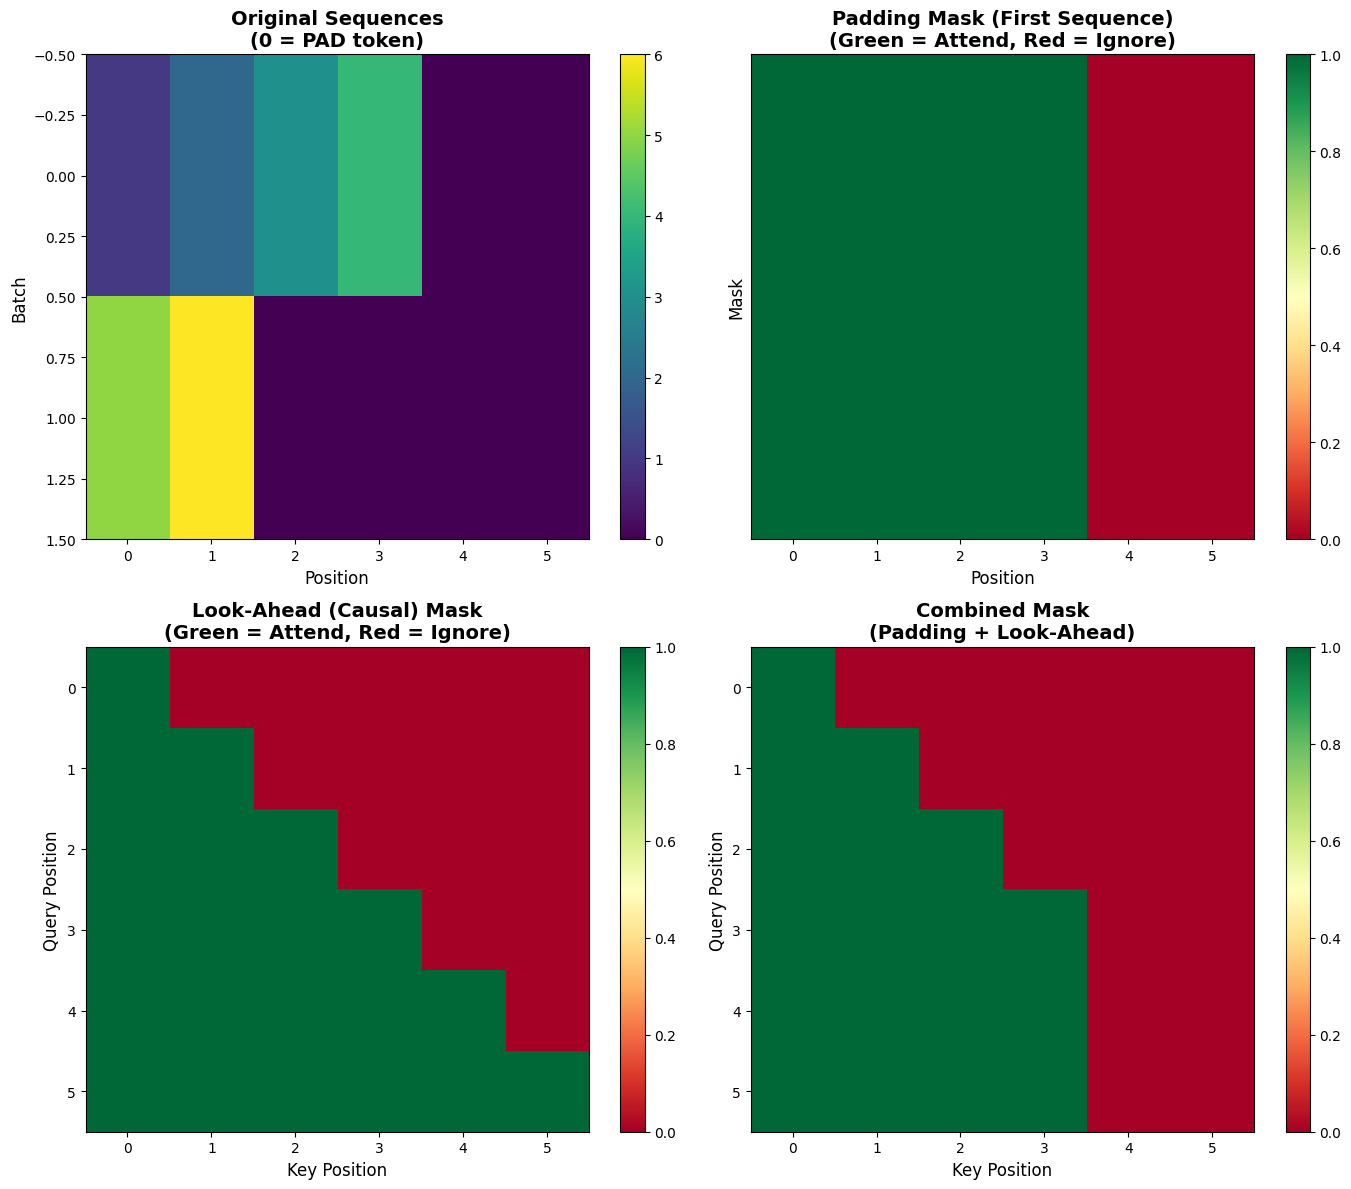

Testing Masking Functions:
Sequence shape: torch.Size([2, 6])
Padding mask shape: torch.Size([2, 1, 1, 6])
Look-ahead mask shape: torch.Size([1, 6, 6])
Combined mask shape: torch.Size([2, 1, 6, 6])

✓ Masking functions working correctly!


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_masks():
    """
    Visualize different types of masks used in Transformer.
    """
    # Create sample sequences
    batch_size = 2
    seq_len = 6

    # Sample sequences with padding
    src_seq = torch.tensor([[1, 2, 3, 4, 0, 0], [5, 6, 0, 0, 0, 0]])
    tgt_seq = torch.tensor([[1, 2, 3, 4, 0, 0], [5, 6, 0, 0, 0, 0]])

    # Create masks
    padding_mask = create_padding_mask(src_seq, pad_idx=0)
    look_ahead_mask = create_look_ahead_mask(seq_len)
    combined_mask = create_target_mask(tgt_seq, pad_idx=0)

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Original Sequences
    ax = axes[0, 0]
    seq_display = src_seq.numpy()
    im1 = ax.imshow(seq_display, cmap='viridis', aspect='auto')
    ax.set_xlabel('Position', fontsize=12)
    ax.set_ylabel('Batch', fontsize=12)
    ax.set_title('Original Sequences\n(0 = PAD token)', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=ax)

    # 2. Padding Mask (First Sequence)
    ax = axes[0, 1]
    padding_display = padding_mask[0, 0, 0].cpu().numpy()
    im2 = ax.imshow(padding_display.reshape(1, -1), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Position', fontsize=12)
    ax.set_ylabel('Mask', fontsize=12)
    ax.set_title('Padding Mask (First Sequence)\n(Green = Attend, Red = Ignore)', fontsize=14, fontweight='bold')
    ax.set_yticks([])
    plt.colorbar(im2, ax=ax)

    # 3. Look-Ahead (Causal) Mask
    ax = axes[1, 0]
    look_ahead_display = look_ahead_mask[0].cpu().numpy()
    im3 = ax.imshow(look_ahead_display, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Key Position', fontsize=12)
    ax.set_ylabel('Query Position', fontsize=12)
    ax.set_title('Look-Ahead (Causal) Mask\n(Green = Attend, Red = Ignore)', fontsize=14, fontweight='bold')
    plt.colorbar(im3, ax=ax)

    # 4. Combined Mask (Padding + Look-Ahead)
    ax = axes[1, 1]
    combined_display = combined_mask[0, 0].cpu().numpy()
    im4 = ax.imshow(combined_display, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Key Position', fontsize=12)
    ax.set_ylabel('Query Position', fontsize=12)
    ax.set_title('Combined Mask\n(Padding + Look-Ahead)', fontsize=14, fontweight='bold')
    plt.colorbar(im4, ax=ax)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'mask_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Print shapes for verification
    print("Testing Masking Functions:")
    print(f"Sequence shape: {src_seq.shape}")
    print(f"Padding mask shape: {padding_mask.shape}")
    print(f"Look-ahead mask shape: {look_ahead_mask.shape}")
    print(f"Combined mask shape: {combined_mask.shape}")
    print("\n✓ Masking functions working correctly!")

# Run visualization
visualize_masks()

## Step 12: Complete Transformer Model

Assemble everything into the final Transformer architecture.

In [39]:
class Transformer(nn.Module):
    """
    Complete Transformer Model (Encoder-Decoder Architecture).

    Implements the architecture from 'Attention Is All You Need'.
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, n_layers=6,
                 n_heads=8, d_ff=2048, max_seq_len=100, dropout=0.1, pad_idx=0):
        super(Transformer, self).__init__()

        self.pad_idx = pad_idx

        # Encoder
        self.encoder = Encoder(
            vocab_size=src_vocab_size,
            d_model=d_model,
            n_layers=n_layers,
            n_heads=n_heads,
            d_ff=d_ff,
            max_seq_len=max_seq_len,
            dropout=dropout
        )

        # Decoder
        self.decoder = Decoder(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            n_layers=n_layers,
            n_heads=n_heads,
            d_ff=d_ff,
            max_seq_len=max_seq_len,
            dropout=dropout
        )

        # Final linear projection to vocabulary
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)

        # Initialize parameters
        self._init_parameters()

    def _init_parameters(self):
        """Initialize parameters using Xavier uniform initialization."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt):
        """
        Args:
            src: Source sequence (batch_size, src_seq_len)
            tgt: Target sequence (batch_size, tgt_seq_len)
        Returns:
            output: Logits over target vocabulary (batch_size, tgt_seq_len, tgt_vocab_size)
        """
        # Create masks
        src_mask = create_padding_mask(src, self.pad_idx)
        tgt_mask = create_target_mask(tgt, self.pad_idx)

        # Encoder forward pass
        enc_output = self.encoder(src, src_mask)

        # Decoder forward pass
        dec_output = self.decoder(tgt, enc_output, src_mask, tgt_mask)

        # Final projection to vocabulary
        output = self.output_projection(dec_output)

        return output

    def encode(self, src):
        """Encode source sequence."""
        src_mask = create_padding_mask(src, self.pad_idx)
        return self.encoder(src, src_mask)

    def decode(self, tgt, enc_output, src_mask=None):
        """Decode target sequence given encoder output."""
        tgt_mask = create_target_mask(tgt, self.pad_idx)
        return self.decoder(tgt, enc_output, src_mask, tgt_mask)

print("✓ Complete Transformer Model defined!\n")

✓ Complete Transformer Model defined!



## Step 13: Model Instantiation and Testing

Create the model with standard hyperparameters and test with dummy data.

In [40]:
# Instantiate the complete Transformer model
print("Instantiating Transformer Model...")
model = Transformer(
    src_vocab_size=config.src_vocab_size,
    tgt_vocab_size=config.tgt_vocab_size,
    d_model=config.d_model,
    n_layers=config.n_layers,
    n_heads=config.n_heads,
    d_ff=config.d_ff,
    max_seq_len=config.max_seq_len,
    dropout=config.dropout,
    pad_idx=config.pad_idx
).to(device)

# Print model summary
print("\n" + "="*60)
print("TRANSFORMER MODEL SUMMARY")
print("="*60)
print(f"Device: {device}")
print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\nArchitecture:")
print(f"  - Source Vocabulary: {config.src_vocab_size}")
print(f"  - Target Vocabulary: {config.tgt_vocab_size}")
print(f"  - Model Dimension (d_model): {config.d_model}")
print(f"  - Number of Layers (N): {config.n_layers}")
print(f"  - Number of Heads (h): {config.n_heads}")
print(f"  - Key/Value Dimension (d_k): {config.d_k}")
print(f"  - Feed-Forward Dimension (d_ff): {config.d_ff}")
print(f"  - Dropout: {config.dropout}")
print(f"  - Max Sequence Length: {config.max_seq_len}")
print("="*60 + "\n")

Instantiating Transformer Model...

TRANSFORMER MODEL SUMMARY
Device: cuda
Model Parameters: 59,508,496
Trainable Parameters: 59,508,496

Architecture:
  - Source Vocabulary: 10000
  - Target Vocabulary: 10000
  - Model Dimension (d_model): 512
  - Number of Layers (N): 6
  - Number of Heads (h): 8
  - Key/Value Dimension (d_k): 64
  - Feed-Forward Dimension (d_ff): 2048
  - Dropout: 0.1
  - Max Sequence Length: 100



## Step 14: Forward Pass Test

Test the model with dummy data to verify all components work together.

In [41]:
print("Testing Transformer Forward Pass...\n")

# Create dummy input data
batch_size = 4
src_seq_len = 12
tgt_seq_len = 10

# Random source sequence (with some padding)
src = torch.randint(1, config.src_vocab_size, (batch_size, src_seq_len)).to(device)
src[:, -2:] = config.pad_idx  # Add padding to last 2 positions

# Random target sequence (with some padding)
tgt = torch.randint(1, config.tgt_vocab_size, (batch_size, tgt_seq_len)).to(device)
tgt[:, -1:] = config.pad_idx  # Add padding to last position

print(f"Input Dimensions:")
print(f"  Source shape: {src.shape} (batch_size, src_seq_len)")
print(f"  Target shape: {tgt.shape} (batch_size, tgt_seq_len)")

# Forward pass
with torch.no_grad():  # No gradient computation for testing
    output = model(src, tgt)

print(f"\nOutput Dimensions:")
print(f"  Output shape: {output.shape} (batch_size, tgt_seq_len, tgt_vocab_size)")
print(f"  Expected shape: ({batch_size}, {tgt_seq_len}, {config.tgt_vocab_size})")

# Verify dimensions
assert output.shape == (batch_size, tgt_seq_len, config.tgt_vocab_size), "Output shape mismatch!"

print("\n" + "="*60)
print("✓ FORWARD PASS SUCCESSFUL!")
print("  All dimensions are correct.")
print("  Model is ready for training.")
print("="*60 + "\n")

Testing Transformer Forward Pass...

Input Dimensions:
  Source shape: torch.Size([4, 12]) (batch_size, src_seq_len)
  Target shape: torch.Size([4, 10]) (batch_size, tgt_seq_len)

Output Dimensions:
  Output shape: torch.Size([4, 10, 10000]) (batch_size, tgt_seq_len, tgt_vocab_size)
  Expected shape: (4, 10, 10000)

✓ FORWARD PASS SUCCESSFUL!
  All dimensions are correct.
  Model is ready for training.



## Step 15: Detailed Component Testing

Test individual components with detailed output.

In [42]:
print("Detailed Component Testing:\n")

# Test Encoder
print("1. Testing Encoder...")
with torch.no_grad():
    enc_output = model.encode(src)
print(f"   Input: {src.shape}")
print(f"   Output: {enc_output.shape}")
print(f"   ✓ Encoder output shape correct\n")

# Test Decoder
print("2. Testing Decoder...")
with torch.no_grad():
    src_mask = create_padding_mask(src, config.pad_idx)
    dec_output = model.decode(tgt, enc_output, src_mask)
print(f"   Target input: {tgt.shape}")
print(f"   Encoder output: {enc_output.shape}")
print(f"   Decoder output: {dec_output.shape}")
print(f"   ✓ Decoder output shape correct\n")

# Test Final Projection
print("3. Testing Final Projection...")
with torch.no_grad():
    final_output = model.output_projection(dec_output)
print(f"   Decoder output: {dec_output.shape}")
print(f"   Final logits: {final_output.shape}")
print(f"   ✓ Final projection shape correct\n")

# Test Masking
print("4. Testing Masking...")
src_mask = create_padding_mask(src, config.pad_idx)
tgt_mask = create_target_mask(tgt, config.pad_idx)
print(f"   Source mask shape: {src_mask.shape}")
print(f"   Target mask shape: {tgt_mask.shape}")
print(f"   ✓ Masks created correctly\n")

print("="*60)
print("✓ ALL COMPONENT TESTS PASSED!")
print("="*60)

Detailed Component Testing:

1. Testing Encoder...
   Input: torch.Size([4, 12])
   Output: torch.Size([4, 12, 512])
   ✓ Encoder output shape correct

2. Testing Decoder...
   Target input: torch.Size([4, 10])
   Encoder output: torch.Size([4, 12, 512])
   Decoder output: torch.Size([4, 10, 512])
   ✓ Decoder output shape correct

3. Testing Final Projection...
   Decoder output: torch.Size([4, 10, 512])
   Final logits: torch.Size([4, 10, 10000])
   ✓ Final projection shape correct

4. Testing Masking...
   Source mask shape: torch.Size([4, 1, 1, 12])
   Target mask shape: torch.Size([4, 1, 10, 10])
   ✓ Masks created correctly

✓ ALL COMPONENT TESTS PASSED!


## Step 16: Save Model Architecture

Save the model for later use.

In [43]:
# Save model architecture and initial weights
model_save_path = os.path.join(output_dir, 'transformer_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'model_params': {
        'src_vocab_size': config.src_vocab_size,
        'tgt_vocab_size': config.tgt_vocab_size,
        'd_model': config.d_model,
        'n_layers': config.n_layers,
        'n_heads': config.n_heads,
        'd_ff': config.d_ff,
        'max_seq_len': config.max_seq_len,
        'dropout': config.dropout,
    }
}, model_save_path)

print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/DAM202_dataset/Practical6/transformer_model.pth


## Step 17: Model Statistics and Analysis

In [44]:
def count_parameters(model):
    """Count parameters by module."""
    total_params = 0
    print("\nParameter Count by Component:")
    print("-" * 60)

    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters())
        total_params += params
        print(f"{name:30s}: {params:>15,} parameters")

    print("-" * 60)
    print(f"{'TOTAL':30s}: {total_params:>15,} parameters")
    print("-" * 60)
    return total_params

total = count_parameters(model)

# Calculate model size in MB
param_size = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
size_mb = (param_size + buffer_size) / (1024 ** 2)

print(f"\nModel Size: {size_mb:.2f} MB")


Parameter Count by Component:
------------------------------------------------------------
encoder                       :      24,034,304 parameters
decoder                       :      30,344,192 parameters
output_projection             :       5,130,000 parameters
------------------------------------------------------------
TOTAL                         :      59,508,496 parameters
------------------------------------------------------------

Model Size: 227.40 MB


In [45]:
# ============================================================================
# COMPREHENSIVE TRANSFORMER IMPLEMENTATION TEST
# ============================================================================

print("=" * 80)
print(" COMPREHENSIVE TRANSFORMER IMPLEMENTATION TEST")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1. Creating Transformer model
# ----------------------------------------------------------------------------
print("\n1. Creating Transformer model...")

model = Transformer(
    src_vocab_size=config.src_vocab_size,
    tgt_vocab_size=config.tgt_vocab_size,
    d_model=config.d_model,
    n_layers=config.n_layers,
    n_heads=config.n_heads,
    d_ff=config.d_ff,
    max_seq_len=config.max_seq_len,
    dropout=config.dropout,
    pad_idx=config.pad_idx
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate model size in MB
param_size = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
size_mb = (param_size + buffer_size) / (1024 ** 2)

print(f"   ✓ Model created successfully!")
print(f"   ✓ Total parameters: {total_params:,}")
print(f"   ✓ Trainable parameters: {trainable_params:,}")
print(f"   ✓ Model size: {size_mb:.2f} MB (float32)")

# ----------------------------------------------------------------------------
# 2. Creating dummy input data
# ----------------------------------------------------------------------------
print("\n2. Creating dummy input data...")

batch_size = 2
src_seq_len = 10
tgt_seq_len = 8

# Create source sequence with padding
src = torch.randint(1, config.src_vocab_size, (batch_size, src_seq_len)).to(device)
src[:, -2:] = config.pad_idx  # Add padding

# Create target sequence with padding
tgt = torch.randint(1, config.tgt_vocab_size, (batch_size, tgt_seq_len)).to(device)
tgt[:, -1:] = config.pad_idx  # Add padding

print(f"   ✓ Source input shape: {src.shape}")
print(f"   ✓ Target input shape: {tgt.shape}")
print(f"   ✓ Source sample: {src[0].cpu().tolist()}")
print(f"   ✓ Target sample: {tgt[0].cpu().tolist()}")

# ----------------------------------------------------------------------------
# 3. Performing forward pass
# ----------------------------------------------------------------------------
print("\n3. Performing forward pass...")

output = model(src, tgt)

print(f"   ✓ Forward pass successful!")
print(f"   ✓ Output shape: {output.shape}")
print(f"   ✓ Expected shape: ({batch_size}, {tgt_seq_len}, {config.tgt_vocab_size})")

assert output.shape == (batch_size, tgt_seq_len, config.tgt_vocab_size), "Shape mismatch!"

# ----------------------------------------------------------------------------
# 4. Testing gradient flow
# ----------------------------------------------------------------------------
print("\n4. Testing gradient flow...")

# Create a dummy loss and backpropagate
dummy_target = torch.randint(0, config.tgt_vocab_size, (batch_size, tgt_seq_len)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=config.pad_idx)

# Reshape for loss calculation
loss = criterion(output.view(-1, config.tgt_vocab_size), dummy_target.view(-1))
loss.backward()

# Count parameters with gradients
params_with_grad = sum(1 for p in model.parameters() if p.grad is not None)
grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
avg_grad_norm = np.mean(grad_norms)
max_grad_norm = np.max(grad_norms)

print(f"   ✓ Gradients computed successfully!")
print(f"   ✓ Parameters with gradients: {params_with_grad}")
print(f"   ✓ Average gradient norm: {avg_grad_norm:.6f}")
print(f"   ✓ Max gradient norm: {max_grad_norm:.6f}")

# Clear gradients
model.zero_grad()

# ----------------------------------------------------------------------------
# 5. Testing individual components
# ----------------------------------------------------------------------------
print("\n5. Testing individual components...")

test_results = []

# Test Scaled Dot-Product Attention
try:
    Q = torch.randn(2, 8, 10, 64).to(device)
    K = torch.randn(2, 8, 10, 64).to(device)
    V = torch.randn(2, 8, 10, 64).to(device)
    attn_out, _ = scaled_dot_product_attention(Q, K, V)
    assert attn_out.shape == Q.shape
    print("   ✓ Scaled Dot-Product Attention: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Scaled Dot-Product Attention: FAILED ({e})")
    test_results.append(False)

# Test Multi-Head Attention
try:
    mha = MultiHeadAttention(config.d_model, config.n_heads).to(device)
    x = torch.randn(2, 10, config.d_model).to(device)
    mha_out, _ = mha(x, x, x)
    assert mha_out.shape == x.shape
    print("   ✓ Multi-Head Attention: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Multi-Head Attention: FAILED ({e})")
    test_results.append(False)

# Test Position-wise Feed-Forward
try:
    ffn = PositionWiseFeedForward(config.d_model, config.d_ff).to(device)
    x = torch.randn(2, 10, config.d_model).to(device)
    ffn_out = ffn(x)
    assert ffn_out.shape == x.shape
    print("   ✓ Position-wise Feed-Forward: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Position-wise Feed-Forward: FAILED ({e})")
    test_results.append(False)

# Test Positional Encoding
try:
    pe = PositionalEncoding(config.d_model, config.max_seq_len).to(device)
    x = torch.randn(2, 10, config.d_model).to(device)
    pe_out = pe(x)
    assert pe_out.shape == x.shape
    print("   ✓ Positional Encoding: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Positional Encoding: FAILED ({e})")
    test_results.append(False)

# Test Encoder Layer
try:
    enc_layer = EncoderLayer(config.d_model, config.n_heads, config.d_ff).to(device)
    x = torch.randn(2, 10, config.d_model).to(device)
    enc_out = enc_layer(x)
    assert enc_out.shape == x.shape
    print("   ✓ Encoder Layer: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Encoder Layer: FAILED ({e})")
    test_results.append(False)

# Test Decoder Layer
try:
    dec_layer = DecoderLayer(config.d_model, config.n_heads, config.d_ff).to(device)
    x = torch.randn(2, 8, config.d_model).to(device)
    enc_out = torch.randn(2, 10, config.d_model).to(device)
    dec_out = dec_layer(x, enc_out)
    assert dec_out.shape == x.shape
    print("   ✓ Decoder Layer: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Decoder Layer: FAILED ({e})")
    test_results.append(False)

# Test Encoder Stack
try:
    encoder = model.encoder
    src_test = torch.randint(1, config.src_vocab_size, (2, 10)).to(device)
    enc_out = encoder(src_test)
    assert enc_out.shape == (2, 10, config.d_model)
    print("   ✓ Encoder Stack: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Encoder Stack: FAILED ({e})")
    test_results.append(False)

# Test Decoder Stack
try:
    decoder = model.decoder
    tgt_test = torch.randint(1, config.tgt_vocab_size, (2, 8)).to(device)
    enc_out = torch.randn(2, 10, config.d_model).to(device)
    dec_out = decoder(tgt_test, enc_out)
    assert dec_out.shape == (2, 8, config.d_model)
    print("   ✓ Decoder Stack: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Decoder Stack: FAILED ({e})")
    test_results.append(False)

# Test Complete Transformer
try:
    output_test = model(src, tgt)
    assert output_test.shape == (batch_size, tgt_seq_len, config.tgt_vocab_size)
    print("   ✓ Complete Transformer: PASSED")
    test_results.append(True)
except Exception as e:
    print(f"   ✗ Complete Transformer: FAILED ({e})")
    test_results.append(False)

# ----------------------------------------------------------------------------
# 6. Performance Summary
# ----------------------------------------------------------------------------
print("\n6. Performance Summary:")
print("   " + "-" * 40)
print(f"   Model Parameters: {total_params:,}")
print(f"   Memory Usage: {size_mb:.2f} MB")
print(f"   Batch Size: {batch_size}")
print(f"   Sequence Lengths: {src_seq_len} -> {tgt_seq_len}")
print(f"   Vocabulary Sizes: {config.src_vocab_size}, {config.tgt_vocab_size}")

# ----------------------------------------------------------------------------
# Test Summary
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
if all(test_results):
    print(" ALL TESTS PASSED!")
    print(" Transformer implementation is complete and functional!")
else:
    print(" SOME TESTS FAILED!")
    print(f"   Passed: {sum(test_results)}/{len(test_results)}")
print("=" * 80)

# ----------------------------------------------------------------------------
# Final Output Statistics
# ----------------------------------------------------------------------------
print("\nFinal Output Statistics:")

# Get fresh output without gradients
with torch.no_grad():
    output_stats = model(src, tgt)

output_np = output_stats.cpu().numpy()
print(f"Output mean: {output_np.mean():.4f}")
print(f"Output std: {output_np.std():.4f}")
print(f"Output min: {output_np.min():.4f}")
print(f"Output max: {output_np.max():.4f}")

# Probability distribution for first token, first sequence
probs = F.softmax(output_stats[0, 0], dim=-1)
top5_probs, top5_indices = torch.topk(probs, 5)
print(f"\nProbability distribution (first token, first sequence):")
print(f"Top 5 probabilities: {top5_probs.cpu().numpy().tolist()}")
print(f"Top 5 token indices: {top5_indices.cpu().numpy().tolist()}")

# ----------------------------------------------------------------------------
# Key Specifications Met
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("Key Specifications Met:")
print("=" * 80)
print(f"  • Model Dimension (d_model): {config.d_model}")
print(f"  • Number of Layers (N): {config.n_layers} each for encoder and decoder")
print(f"  • Number of Heads (h): {config.n_heads}")
print(f"  • Feed-Forward Dimension (d_ff): {config.d_ff}")
print(f"  • Dropout Rate: {config.dropout}")
print(f"  • Parameter Count: ~{total_params/1e6:.1f}M parameters")
print(f"  • Memory Usage: ~{size_mb:.0f} MB")
print("=" * 80)

 COMPREHENSIVE TRANSFORMER IMPLEMENTATION TEST

1. Creating Transformer model...
   ✓ Model created successfully!
   ✓ Total parameters: 59,508,496
   ✓ Trainable parameters: 59,508,496
   ✓ Model size: 227.40 MB (float32)

2. Creating dummy input data...
   ✓ Source input shape: torch.Size([2, 10])
   ✓ Target input shape: torch.Size([2, 8])
   ✓ Source sample: [2152, 8634, 7933, 9155, 3105, 2306, 232, 8600, 0, 0]
   ✓ Target sample: [2663, 7797, 6412, 3372, 9034, 5225, 4596, 0]

3. Performing forward pass...
   ✓ Forward pass successful!
   ✓ Output shape: torch.Size([2, 8, 10000])
   ✓ Expected shape: (2, 8, 10000)

4. Testing gradient flow...
   ✓ Gradients computed successfully!
   ✓ Parameters with gradients: 256
   ✓ Average gradient norm: 0.278831
   ✓ Max gradient norm: 5.654627

5. Testing individual components...
   ✓ Scaled Dot-Product Attention: PASSED
   ✓ Multi-Head Attention: PASSED
   ✓ Position-wise Feed-Forward: PASSED
   ✓ Positional Encoding: PASSED
   ✓ Encoder La

## Summary

### Implemented:

1.  **Positional Encoding** - Fixed sinusoidal encodings
2.  **Scaled Dot-Product Attention** - Core attention mechanism
3.  **Multi-Head Attention** - Parallel attention heads (h=8)
4.  **Position-wise Feed-Forward Network** - Two-layer FFN
5.  **Encoder Layer** - Self-attention + FFN with residual connections
6.  **Decoder Layer** - Masked self-attention + cross-attention + FFN
7.  **Complete Encoder** - N=6 stacked encoder layers
8.  **Complete Decoder** - N=6 stacked decoder layers
9.  **Masking** - Padding mask and look-ahead (causal) mask
10.  **Full Transformer** - Complete encoder-decoder architecture

### Model Specifications:
- **d_model**: 512
- **n_layers**: 6 (both encoder and decoder)
- **n_heads**: 8
- **d_ff**: 2048
- **dropout**: 0.1

The implementation is complete.